In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
def plot_lineplot(file_dict, metric='F1 Score'):
    processed_data = []
    for model_name, file_paths in file_dict.items():
        if not file_paths:
            raise ValueError(f"No file paths provided for model: {model_name}")

        for file_path in file_paths:
            try:
                method_match = re.search(r'_(GP|DAPS)_', file_path, re.IGNORECASE)
                patches_match = re.search(r'(?:in_channels|num_patches)_(\d+)', file_path, re.IGNORECASE)

                if not method_match or not patches_match:
                    raise ValueError(f"File path {file_path} does not match expected format.")

                method = method_match.group(1)
                if method == 'GP':
                    display_method = 'MetImage(GP)'
                elif method == 'DAPS':
                    display_method = 'MSIMG(DAPS)'
                else:
                    raise ValueError(f"Unexpected method found in file path: {file_path}")
                num_patches = int(patches_match.group(1))

                df_summary = pd.read_csv(file_path, index_col='Metric')
                summary_row = df_summary.loc[metric]
                mean_val = summary_row['Mean_Test_on_Holdout']
                ci_lower = summary_row['95% CI Lower']
                ci_upper = summary_row['95% CI Upper']

                processed_data.append({
                    'Model': model_name,
                    'Method': display_method,
                    'Num Patches': num_patches,
                    'Metric': mean_val,
                    'CI Lower': ci_lower,
                    'CI Upper': ci_upper
                })
            except ValueError as e:
                raise ValueError(f"File path {file_path} does not match expected format.")

    if not processed_data:
        raise ValueError("No valid data to plot.")

    df_long = pd.DataFrame(processed_data)

    sns.set_theme(style='whitegrid', font_scale=1.2)
    methods_to_plot = ['MetImage(GP)', 'MSIMG(DAPS)']
    # 'viridis', 'plasma', 'magma', 'cividis', 'Set2', 'Paired', 'tab10'
    colormap_name = 'tab10'
    colors = sns.color_palette(colormap_name, n_colors=2)
    palette = {
        'MetImage(GP)': colors[0],
        'MSIMG(DAPS)': colors[1]
    }
    linestyles = {'MetImage(GP)': '--', 'MSIMG(DAPS)': '-'}
    markers = {'MetImage(GP)': 's', 'MSIMG(DAPS)': 'o'}

    model_order = ['ResNet50', 'DenseNet121', 'EfficientNetB0']
    fig, axes = plt.subplots(1, len(model_order), figsize=(7 * len(model_order), 6))
    for i, model_name in enumerate(model_order):
        ax = axes[i]
        model_data = df_long[df_long['Model'] == model_name]

        for method in methods_to_plot:
            method_data = model_data[model_data['Method'] == method].sort_values('Num Patches')
            if method_data.empty:
                continue
            ax.plot(
                method_data['Num Patches'], method_data['Metric'],
                label=method, color=palette[method], linestyle=linestyles[method],
                marker=markers[method], linewidth=2.5, markersize=8
            )
            ax.fill_between(
                method_data['Num Patches'], method_data['CI Lower'], method_data['CI Upper'],
                color=palette[method], alpha=0.15
            )
        ax.set_title(f'Backbone: {model_name}', fontsize=20, pad=12)
        ax.set_xscale('log', base=2)
        ax.set_xticks(sorted(df_long['Num Patches'].unique()))
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.grid(True, which='both', ls='--', c='0.7')
        ax.set_xlabel('Number of Patches', fontsize=20)
        ax.legend(loc='lower right', fontsize=16)

    axes[0].set_ylabel(metric, fontsize=20)
    plt.tight_layout()

    file_name = f"Comparison of {metric} between MetImage(GP) and MSIMG(DAPS) with a varying number of input patches"
    plt.savefig(f"{file_name}.svg", bbox_inches='tight')
    # plt.savefig(f"{file_name}.tiff", dpi=300, pil_kwargs={'compression': 'tiff_lzw'}, bbox_inches='tight')
    plt.show()

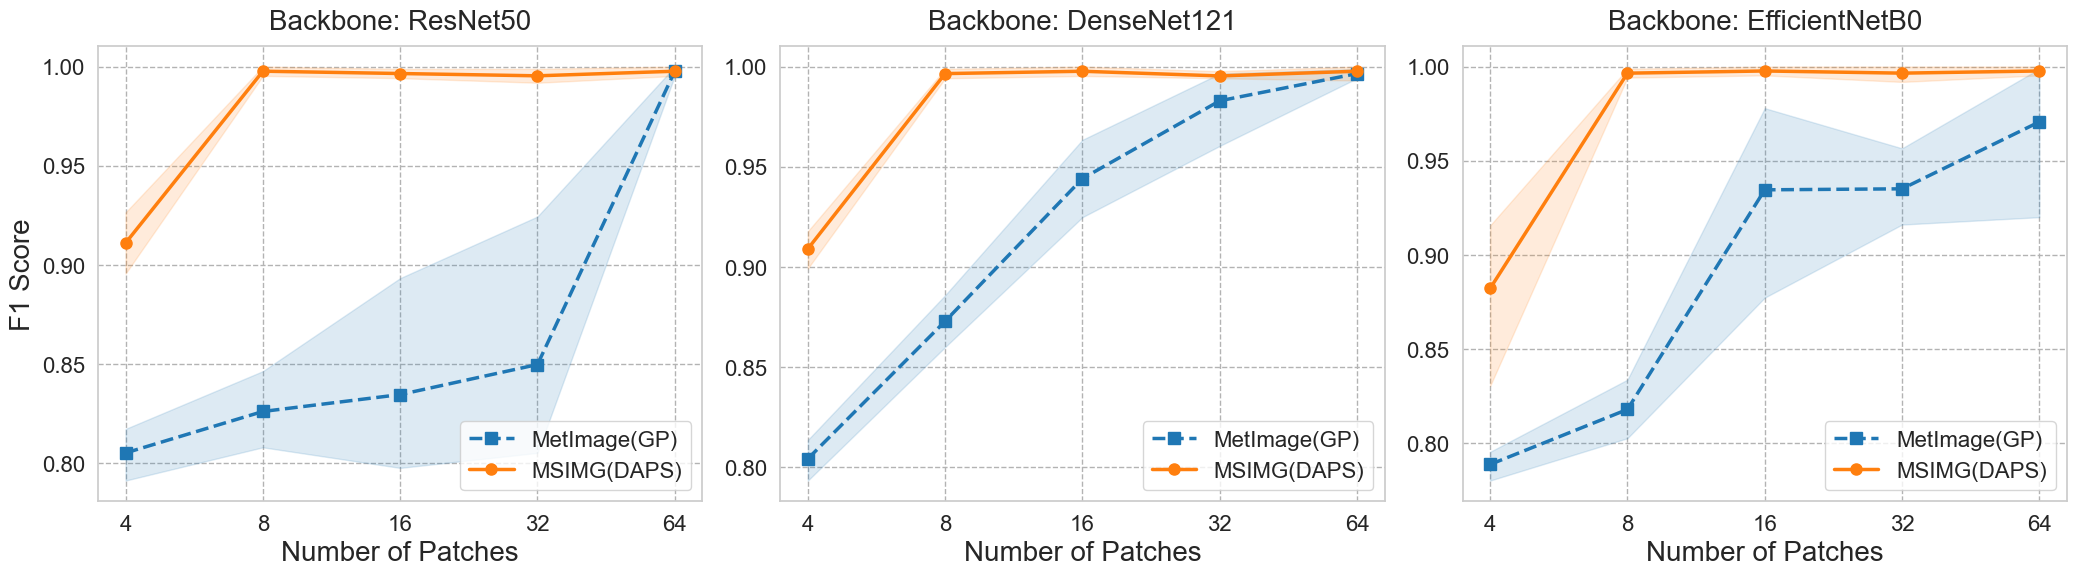

In [19]:
import os
from collections import defaultdict
dataset_name = 'SPNS'
file_dict = defaultdict(list)
for model_name in ['ResNet50', 'DenseNet121', 'EfficientNetB0']:
    for method_name in ['GP', 'DAPS']:
        for num_patches in [4, 8, 16, 32, 64]:
            file_path = f"experiment_results/{dataset_name}/{model_name}_{dataset_name}_{method_name}_PATCH_224x224_IN_CHANNELS_{num_patches}_NUM_CLASSES_2_BATCH_SIZE_8/{model_name}_{dataset_name}_num_classes_2_in_channels_{num_patches}_kfold_tested_on_holdout_summary_stats.csv"
            if not os.path.exists(file_path):
                raise ValueError(f"File path {file_path} does not match expected format.")
            file_dict[model_name].append(file_path)
plot_lineplot(file_dict, metric='F1 Score')


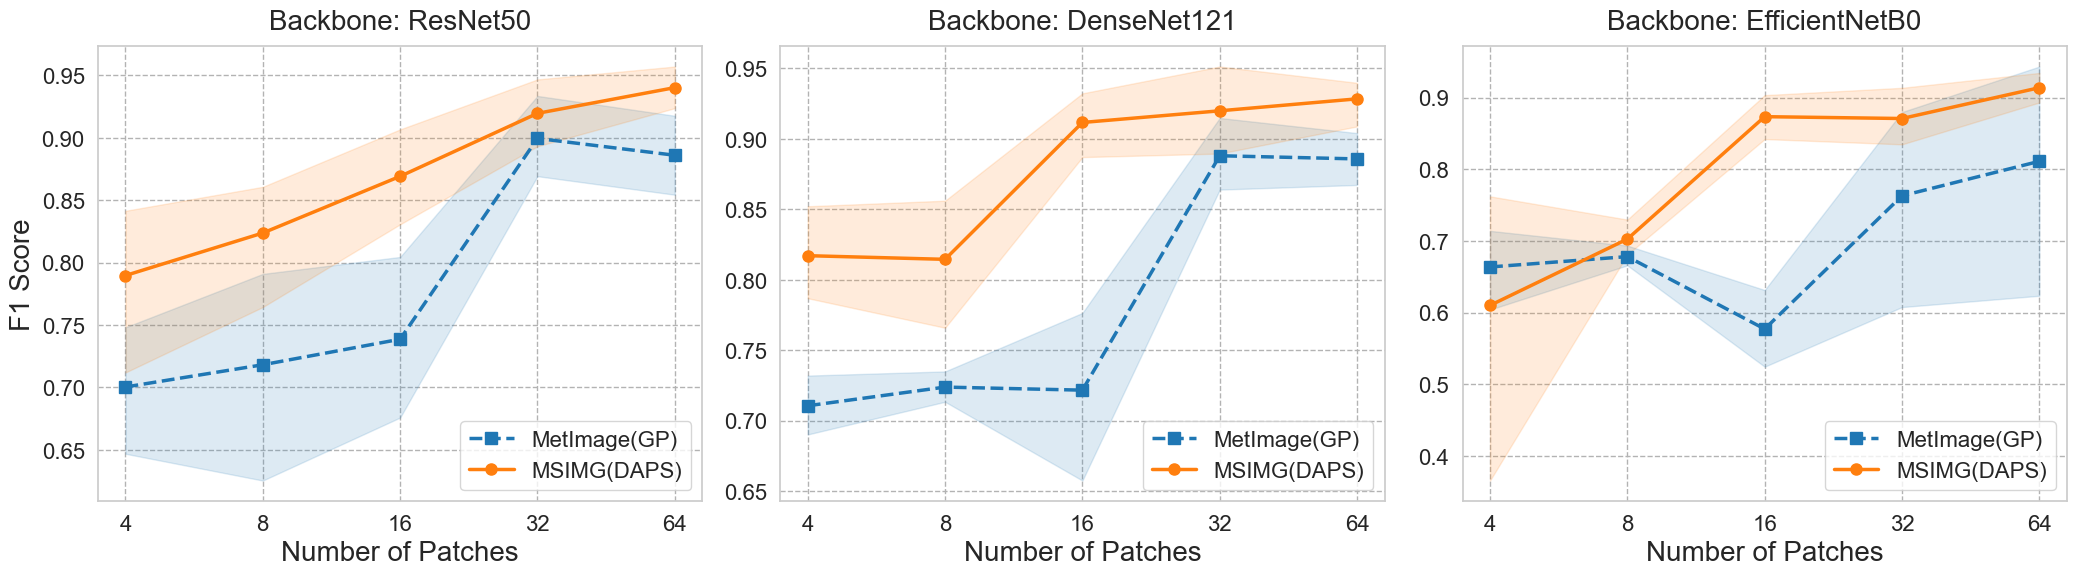

In [20]:
dataset_name = 'CD'
file_dict = defaultdict(list)
for model_name in ['ResNet50', 'DenseNet121', 'EfficientNetB0']:
    for method_name in ['GP', 'DAPS']:
        for num_patches in [4, 8, 16, 32, 64]:
            file_path = f"experiment_results/{dataset_name}/{model_name}_{dataset_name}_{method_name}_PATCH_224x224_IN_CHANNELS_{num_patches}_NUM_CLASSES_2_BATCH_SIZE_8/{model_name}_{dataset_name}_num_classes_2_in_channels_{num_patches}_kfold_tested_on_holdout_summary_stats.csv"
            if not os.path.exists(file_path):
                raise ValueError(f"File path {file_path} does not match expected format.")
            file_dict[model_name].append(file_path)
plot_lineplot(file_dict, metric='F1 Score')

In [15]:
def plot_grouped_boxplot(file_dict, metric='F1 Score'):
    processed_data = []
    for model_name, file_paths in file_dict.items():
        if not file_paths:
            raise ValueError(f"File path {file_paths} does not match expected format.")

        for file_path in file_paths:
            try:
                method_match = re.search(r'_(GP|DAPS)_', file_path, re.IGNORECASE)
                patch_size_match = re.search(r'_PATCH_(\d+)x\d+_', file_path, re.IGNORECASE)

                if not method_match or not patch_size_match:
                    raise ValueError(f"File path {file_path} does not match expected format.")

                method = method_match.group(1).upper() # Use .upper() for consistency
                if method == 'GP':
                    display_method = 'MetImage(GP)'
                elif method == 'DAPS':
                    display_method = 'MSIMG(DAPS)'
                else:
                    raise ValueError(f"Unexpected method found in file path: {file_path}")
                patch_size = int(patch_size_match.group(1))

                df_folds = pd.read_csv(file_path)
                for value in df_folds[metric].dropna():
                    processed_data.append({
                        'Model': model_name,
                        'Patch Size': patch_size,
                        'Method': display_method,
                        metric: value
                    })
            except Exception as e:
                raise ValueError(f"Error processing file path {file_path}: {e}")

    if not processed_data:
        raise ValueError("No valid data to plot.")

    df_long = pd.DataFrame(processed_data)

    sns.set_theme(style='whitegrid', font_scale=1.2)
    methods_to_plot = ['MetImage(GP)', 'MSIMG(DAPS)']
    colormap_name = 'tab10'
    colors = sns.color_palette(colormap_name, n_colors=2)
    palette = {
        'MetImage(GP)': colors[0],
        'MSIMG(DAPS)': colors[1]
    }

    model_order = ['ResNet50', 'DenseNet121', 'EfficientNetB0']
    fig, axes = plt.subplots(1, len(model_order), figsize=(8 * len(model_order), 7), sharey=True)

    for i, model_name in enumerate(model_order):
        ax = axes[i]
        model_data = df_long[df_long['Model'] == model_name]

        patch_sizes = sorted(model_data['Patch Size'].unique())
        x_locs = np.arange(len(patch_sizes))

        offset = 0.2
        box_width = 0.35

        for j, method in enumerate(methods_to_plot):
            data_to_plot = [
                model_data[(model_data['Method'] == method) & (model_data['Patch Size'] == p)][metric].values
                for p in patch_sizes
            ]
            positions = x_locs + offset * (j - 0.5) * 2

            bp = ax.boxplot(data_to_plot, positions=positions, widths=box_width, patch_artist=True, manage_ticks=False,
                            showfliers=False)

            for patch in bp['boxes']:
                patch.set_facecolor(palette[method])
                patch.set_alpha(0.7)

            jitter_width = box_width * 0.2

            for k, p_size in enumerate(patch_sizes):
                y_values = data_to_plot[k]
                x_center = positions[k]
                x_jittered = np.random.normal(loc=x_center, scale=jitter_width, size=len(y_values))

                ax.scatter(
                    x_jittered,
                    y_values,
                    color=palette[method],
                    s=30,
                    alpha=0.6,
                    edgecolor='black',
                    linewidth=0.5,
                    zorder=10
                )

        ax.set_title(f"Backbone: {model_name}", fontsize=20, pad=12)
        ax.tick_params(axis='y', labelleft=True, labelsize=20)
        ax.set_xticks(x_locs)
        ax.set_xticklabels([f"{p}x{p}" for p in patch_sizes], fontsize=16)
        ax.set_xlabel('Patch Size', fontsize=20)
        # ax.legend(
        #     [
        #     plt.Rectangle((0, 0), 1, 1, facecolor=palette[m], alpha=0.7)
        #     for m in methods_to_plot
        #     ],
        #     methods_to_plot,
        #     loc='lower right',
        #     fontsize=14
        # )
        leg = ax.legend(
            [
            plt.Rectangle((0, 0), 1, 1, facecolor=palette[m], alpha=0.7)
            for m in methods_to_plot
            ],
            methods_to_plot,
            loc='lower right',
            fontsize=16
        )

        leg.set_zorder(20)

    axes[0].set_ylabel(metric, fontsize=20)
    plt.tight_layout()

    file_name = f"Comparison of {metric} between MetImage(GP) and MSIMG(DAPS) with a varying size of input patches"
    plt.savefig(f"{file_name}.svg", bbox_inches='tight')
    plt.show()

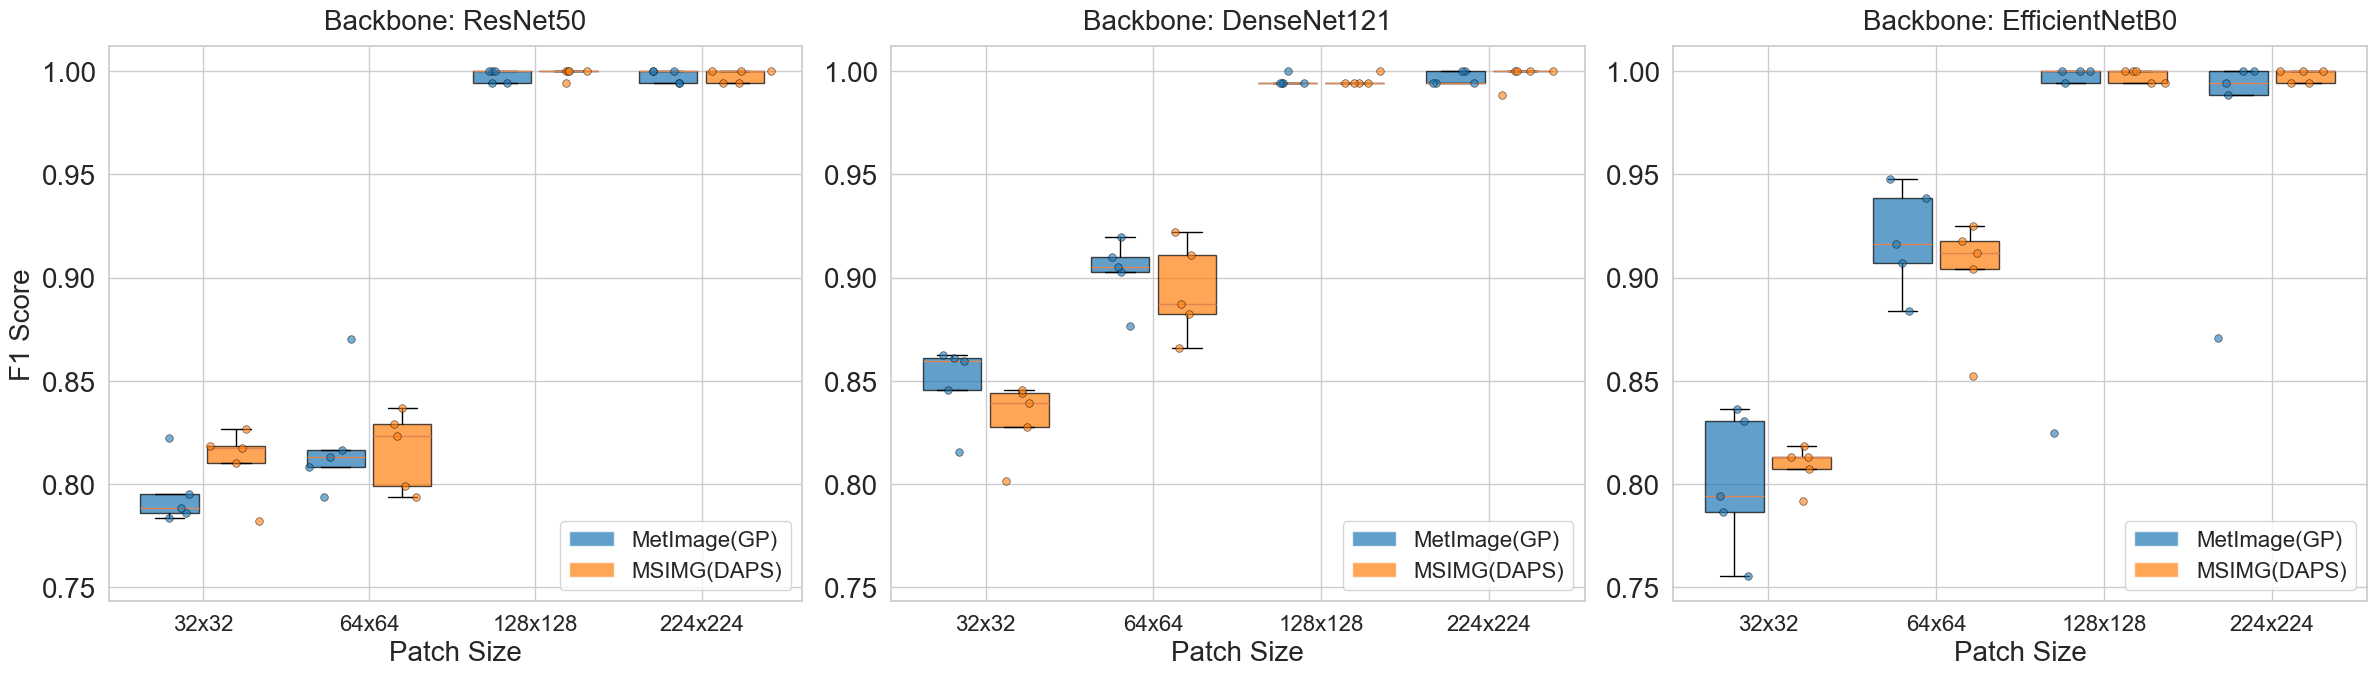

In [17]:
import os
from collections import defaultdict
dataset_name = 'SPNS'
file_dict = defaultdict(list)
for model_name in ['ResNet50', 'DenseNet121', 'EfficientNetB0']:
    for method_name in ['GP', 'DAPS']:
        for patch_size in [32, 64, 128, 224]:
            file_path = f"experiment_results/{dataset_name}/{model_name}_{dataset_name}_{method_name}_PATCH_{patch_size}x{patch_size}_IN_CHANNELS_64_NUM_CLASSES_2_BATCH_SIZE_8/{model_name}_{dataset_name}_num_classes_2_in_channels_64_kfold_tested_on_holdout_metrics.csv"
            if not os.path.exists(file_path):
                raise ValueError(f"File path {file_path} does not match expected format.")
            file_dict[model_name].append(file_path)
plot_grouped_boxplot(file_dict, metric='F1 Score')